# Toxic Comment Detection using Bi-LSTM with Dual Embeddings

**NLP Assessment 3 — Project Development**

Online platforms face the constant challenge of identifying toxic, hateful, or abusive
comments before they harm communities.  Manual moderation does not scale to millions of
daily posts, making **automated toxic comment detection** a high-impact NLP problem.

In this notebook we:
1. Download and preprocess the **Jigsaw Toxic Comment Classification** dataset.
2. Train a **baseline Simple LSTM** model as the reference.
3. Train our **proposed model — Bidirectional LSTM with Dual Embeddings**
   (pretrained GloVe + task-specific trainable embeddings).
4. Compare both models using accuracy, F1-score, and confusion matrices.

The full code lives in this notebook; a link to the public GitHub repository is provided in
the report.


## 1. Install libraries and import dependencies

In [ ]:
# Install required libraries
!pip install kagglehub torch scikit-learn matplotlib seaborn pandas requests > /dev/null

import os, random, re, requests, zipfile, io, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score,
                              classification_report, confusion_matrix)
import kagglehub, glob, zipfile
from collections import Counter

warnings.filterwarnings("ignore")

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cpu


## 2. Download the Jigsaw Toxic Comment dataset

We use `kagglehub` to download the competition data directly.
Make sure your Kaggle API credentials are configured
(`~/.kaggle/kaggle.json` or `KAGGLE_USERNAME` / `KAGGLE_KEY` environment variables).

The training file `train.csv` contains ~160 k Wikipedia comments, each labelled with six
binary toxicity categories.  For this binary classification project we predict the
**`toxic`** column (1 = toxic, 0 = non-toxic).


In [ ]:
import kagglehub
kagglehub.login()


Kaggle credentials set.
Kaggle credentials successfully validated.


In [ ]:
import kagglehub, glob, zipfile, os

# Download competition files (cached after first run)
path = kagglehub.competition_download("jigsaw-toxic-comment-classification-challenge")
print("Downloaded to:", path)

# ── List everything that was downloaded ───────────────────────────────────────
all_files = []
for root, dirs, files in os.walk(path):
    for f in files:
        all_files.append(os.path.join(root, f))
print("Files found:", all_files)

# ── Extract any zip files ─────────────────────────────────────────────────────
for fpath in all_files:
    if fpath.endswith(".zip"):
        print(f"Extracting {fpath} ...")
        with zipfile.ZipFile(fpath, "r") as z:
            z.extractall(os.path.dirname(fpath))
        print("Extracted.")






100%|██████████| 52.6M/52.6M [00:00<00:00, 97.4MB/s]

Extracting files...


Downloaded to: /root/.cache/kagglehub/competitions/jigsaw-toxic-comment-classification-challenge
Files found: ['/root/.cache/kagglehub/competitions/jigsaw-toxic-comment-classification-challenge/train.csv.zip', '/root/.cache/kagglehub/competitions/jigsaw-toxic-comment-classification-challenge/test_labels.csv.zip', '/root/.cache/kagglehub/competitions/jigsaw-toxic-comment-classification-challenge/sample_submission.csv.zip', '/root/.cache/kagglehub/competitions/jigsaw-toxic-comment-classification-challenge/test.csv.zip']
Extracting /root/.cache/kagglehub/competitions/jigsaw-toxic-comment-classification-challenge/train.csv.zip ...
Extracted.
Extracting /root/.cache/kagglehub/competitions/jigsaw-toxic-comment-classification-challenge/test_labels.csv.zip ...
Extracted.
Extracting /root/.cache/kagglehub/competitions/jigsaw-toxic-comment-classification-challenge/sample_submission.csv.zip ...
Extracted.
Extracting /root/.cache/kagglehub/competitions/jigsaw-toxic-comment-classification-challenge

In [ ]:
# ── Find train.csv (search again after extraction) ───────────────────────────
csv_files = glob.glob(os.path.join(path, "**", "train.csv"), recursive=True)
if not csv_files:
    csv_files = glob.glob(os.path.join(path, "*.csv"))
print("CSV files found:", csv_files)

TRAIN_CSV = csv_files[0] if csv_files else None
if TRAIN_CSV is None:
    raise FileNotFoundError(
        "train.csv not found after extraction. "
        "Check the files listed above and set TRAIN_CSV manually.")
print(f"Using: {TRAIN_CSV}")

CSV files found: ['/root/.cache/kagglehub/competitions/jigsaw-toxic-comment-classification-challenge/train.csv']
Using: /root/.cache/kagglehub/competitions/jigsaw-toxic-comment-classification-challenge/train.csv


## 3. Load and explore the data

The dataset has six toxicity labels.  We work with the **`toxic`** column as our target.
Because the full dataset is large (~160 k rows), we sample a balanced subset that fits
comfortably within Colab's free-tier resources.


In [ ]:
# ── Hyper-parameters ──────────────────────────────────────────────────────────
N_SAMPLES_PER_CLASS = 5000   # samples per class for balanced subset (adjust freely)
MAX_SEQ_LEN         = 100    # max tokens per comment
MIN_WORD_FREQ       = 2      # min frequency for vocabulary inclusion
# ──────────────────────────────────────────────────────────────────────────────

df_full = pd.read_csv(TRAIN_CSV)
print(f"Full dataset shape: {df_full.shape}")
print(f"Columns: {list(df_full.columns)}")

# Keep only the text and the binary toxic label
df = df_full[["comment_text", "toxic"]].copy()
df = df.rename(columns={"comment_text": "text", "toxic": "label"})
df = df.dropna()

# Class distribution before sampling
print("\nFull label distribution:")
print(df["label"].value_counts())

# ── Balanced subsample ────────────────────────────────────────────────────────
toxic_df    = df[df["label"] == 1].sample(
    min(N_SAMPLES_PER_CLASS, (df["label"] == 1).sum()),
    random_state=SEED)
nontoxic_df = df[df["label"] == 0].sample(
    min(N_SAMPLES_PER_CLASS, (df["label"] == 0).sum()),
    random_state=SEED)

df = pd.concat([toxic_df, nontoxic_df]).sample(frac=1, random_state=SEED).reset_index(drop=True)
print(f"\nBalanced subset: {len(df)} samples")
print(df["label"].value_counts())

# Preview
df[["text", "label"]].head(3)


Full dataset shape: (159571, 8)
Columns: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

Full label distribution:
label
0    144277
1     15294
Name: count, dtype: int64

Balanced subset: 10000 samples
label
0    5000
1    5000
Name: count, dtype: int64


,text,label
0,It is an improvement so I won't comment on the...,0
1,WHAT?! \n\nMalta is an Arab! Stop pussying aro...,1
2,So you don't understand english and you're par...,1


## 4. Text preprocessing

We apply light normalisation — lowercase, remove URLs and special characters — and build a
word-level vocabulary from the **training split only** to prevent data leakage.
Unknown words at inference time are mapped to `<UNK>`; sequences are zero-padded or
truncated to `MAX_SEQ_LEN`.


In [ ]:
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

def tokenize(text):
    """Lowercase, remove URLs and non-alpha characters, split on whitespace."""
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)       # strip URLs
    text = re.sub(r"[^a-z\s]", " ", text)                 # keep letters only
    text = re.sub(r"\s+", " ", text).strip()
    return text.split()

# ── Train / validation / test split ──────────────────────────────────────────
train_df, temp_df = train_test_split(
    df, test_size=0.3, random_state=SEED, stratify=df["label"])
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=SEED, stratify=temp_df["label"])

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)
print(f"Train: {len(train_df)}  |  Val: {len(val_df)}  |  Test: {len(test_df)}")

# ── Build vocabulary on TRAINING data only ────────────────────────────────────
word_freq = Counter()
for text in train_df["text"]:
    word_freq.update(tokenize(text))

vocab = [PAD_TOKEN, UNK_TOKEN] + [
    w for w, f in word_freq.most_common() if f >= MIN_WORD_FREQ
]
word2idx  = {w: i for i, w in enumerate(vocab)}
VOCAB_SIZE = len(vocab)
print(f"Vocabulary size: {VOCAB_SIZE:,}")

def encode(text, word2idx, max_len):
    """Convert text to a zero-padded list of token indices."""
    tokens = tokenize(text)[:max_len]
    ids    = [word2idx.get(t, word2idx[UNK_TOKEN]) for t in tokens]
    ids   += [word2idx[PAD_TOKEN]] * (max_len - len(ids))
    return ids

X_train = np.array([encode(t, word2idx, MAX_SEQ_LEN) for t in train_df["text"]])
y_train = np.array(train_df["label"].tolist())

X_val   = np.array([encode(t, word2idx, MAX_SEQ_LEN) for t in val_df["text"]])
y_val   = np.array(val_df["label"].tolist())

X_test  = np.array([encode(t, word2idx, MAX_SEQ_LEN) for t in test_df["text"]])
y_test  = np.array(test_df["label"].tolist())

print(f"X_train: {X_train.shape}  |  X_val: {X_val.shape}  |  X_test: {X_test.shape}")


Train: 7000  |  Val: 1500  |  Test: 1500
Vocabulary size: 12,151
X_train: (7000, 100)  |  X_val: (1500, 100)  |  X_test: (1500, 100)


## 5. Load pretrained GloVe embeddings

We use **GloVe 6B 50-dimensional** vectors pre-trained on 6 billion tokens from Wikipedia
and Gigaword.  For each word in our vocabulary we look up its GloVe vector; words not in
GloVe receive a zero vector.  This matrix will initialise the *pretrained* embedding stream
of our Bi-LSTM.


In [ ]:
EMBED_DIM_GLOVE     = 50
EMBED_DIM_TRAINABLE = 50

GLOVE_URL  = "https://nlp.stanford.edu/data/glove.6B.zip"
GLOVE_FILE = "glove.6B.50d.txt"

def download_glove(url=GLOVE_URL, txt_file=GLOVE_FILE):
    if os.path.exists(txt_file):
        print(f"'{txt_file}' already present — skipping download.")
        return
    print("Downloading GloVe 6B embeddings (~82 MB)…")
    response = requests.get(url, stream=True)
    z = zipfile.ZipFile(io.BytesIO(response.content))
    z.extract(txt_file)
    print("Download complete.")

download_glove()

def load_glove_vectors(glove_file, embed_dim):
    glove = {}
    with open(glove_file, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.split()
            word  = parts[0]
            vec   = np.array(parts[1:], dtype=np.float32)
            if vec.shape[0] == embed_dim:
                glove[word] = vec
    print(f"Loaded {len(glove):,} GloVe vectors.")
    return glove

glove_vectors = load_glove_vectors(GLOVE_FILE, EMBED_DIM_GLOVE)

def build_embedding_matrix(word2idx, glove_vectors, embed_dim):
    matrix = np.zeros((len(word2idx), embed_dim), dtype=np.float32)
    found = 0
    for word, idx in word2idx.items():
        if word in glove_vectors:
            matrix[idx] = glove_vectors[word]
            found += 1
    coverage = found / len(word2idx) * 100
    print(f"Embedding matrix: {matrix.shape}  |  "
          f"GloVe coverage: {found}/{len(word2idx)} words ({coverage:.1f}%)")
    return matrix

glove_matrix = build_embedding_matrix(word2idx, glove_vectors, EMBED_DIM_GLOVE)


Download complete.
Loaded 400,000 GloVe vectors.
Embedding matrix: (12151, 50)  |  GloVe coverage: 11298/12151 words (93.0%)


## 6. PyTorch Dataset and DataLoader

In [ ]:
BATCH_SIZE = 64

class CommentDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = CommentDataset(X_train, y_train)
val_dataset   = CommentDataset(X_val,   y_val)
test_dataset  = CommentDataset(X_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}  "
      f"|  Val batches: {len(val_loader)}  "
      f"|  Test batches: {len(test_loader)}")


Train batches: 110  |  Val batches: 24  |  Test batches: 24


## 7. Baseline model — Simple LSTM

The baseline uses a **single randomly-initialised embedding layer** fed into a
**unidirectional LSTM**.  The final hidden state is passed through a dropout layer and a
linear classifier.

This represents a standard "off-the-shelf" approach and sets the performance floor for our
comparison.


In [ ]:
class SimpleLSTM(nn.Module):
    """
    Baseline: single trainable embedding + unidirectional LSTM + classifier.

    Architecture
    ------------
    tokens  (B, T)
      └─ Embedding  (vocab_size, embed_dim)     [trainable, random init]
      └─ LSTM       (embed_dim → hidden_dim)    [1 layer, unidirectional]
      └─ Dropout
      └─ Linear     (hidden_dim → 2)
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim,
                 num_classes, pad_idx, dropout=0.4):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm      = nn.LSTM(embed_dim, hidden_dim,
                                 batch_first=True, bidirectional=False)
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))      # (B, T, E)
        _, (h, _) = self.lstm(emb)                 # h: (1, B, H)
        out = self.dropout(h.squeeze(0))           # (B, H)
        return self.fc(out)                        # (B, C)


HIDDEN_DIM  = 128
PAD_IDX     = word2idx[PAD_TOKEN]
NUM_CLASSES = 2
NUM_EPOCHS  = 10

baseline_model = SimpleLSTM(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM_GLOVE,
    hidden_dim=HIDDEN_DIM,
    num_classes=NUM_CLASSES,
    pad_idx=PAD_IDX,
).to(DEVICE)

n_params = sum(p.numel() for p in baseline_model.parameters() if p.requires_grad)
print(f"SimpleLSTM  |  Trainable parameters: {n_params:,}")
print(baseline_model)


SimpleLSTM  |  Trainable parameters: 699,968
SimpleLSTM(
  (embedding): Embedding(12151, 50, padding_idx=0)
  (lstm): LSTM(50, 128, batch_first=True)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)


## 8. Proposed model — Bi-LSTM with Dual Embeddings

### Why this architecture?

**Challenge 1 — Limited labelled data for toxic language.**  
Toxic comments are relatively rare in the wild.  Pretrained GloVe vectors provide semantic
knowledge of words (including slurs, intensifiers, and abusive vocabulary) learned from
billions of tokens without needing labelled toxic examples.

**Challenge 2 — Context polarity.**  
The same word can be benign or toxic depending on surrounding context
(*"I hate broccoli"* vs. *"I hate you"*).  A unidirectional LSTM can miss right-to-left
cues.  A **Bidirectional LSTM** reads the sequence in both directions, giving each token
access to its full sentence context.

**Challenge 3 — Generalisation vs. specialisation.**  
A single embedding must balance general semantics and task-specific surface cues.
By using **two separate embedding layers** concatenated together — one pretrained (GloVe)
and one freely trainable — the model can preserve broad linguistic knowledge while also
learning patterns specific to online toxic language (abbreviations, intentional
misspellings, punctuation patterns).

### Architecture summary

```
tokens (B, T)
  ├─ Embed-1: GloVe 50d  (pretrained, fine-tunable) ──┐
  └─ Embed-2: Trainable 50d (random init)             ─┤ cat → (B, T, 100)
                                                        │
  └─ Dropout
  └─ Bi-LSTM (100 → hidden_dim, bidirectional)
       fwd hidden ──┐
       bwd hidden ──┘ cat → (B, hidden_dim × 2)
  └─ Dropout
  └─ Linear (hidden_dim×2 → 2)
```


In [ ]:
class BiLSTMDualEmbed(nn.Module):
    """
    Proposed model: dual embeddings (GloVe + trainable) + Bi-LSTM + classifier.
    """
    def __init__(self, vocab_size, glove_dim, train_dim,
                 hidden_dim, num_classes, pad_idx,
                 glove_matrix, dropout=0.4):
        super().__init__()

        # ── Embedding-1: GloVe pretrained (fine-tunable) ─────────────────────
        self.embed_glove = nn.Embedding(vocab_size, glove_dim, padding_idx=pad_idx)
        self.embed_glove.weight = nn.Parameter(
            torch.tensor(glove_matrix, dtype=torch.float))
        self.embed_glove.weight.requires_grad = True   # allow fine-tuning

        # ── Embedding-2: Task-specific trainable ─────────────────────────────
        self.embed_train = nn.Embedding(vocab_size, train_dim, padding_idx=pad_idx)
        nn.init.xavier_uniform_(self.embed_train.weight.data[2:])

        # ── Bi-LSTM encoder ──────────────────────────────────────────────────
        self.lstm = nn.LSTM(
            input_size=glove_dim + train_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True,
            num_layers=1,
        )
        self.dropout = nn.Dropout(dropout)

        # ── Classifier ───────────────────────────────────────────────────────
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        e1  = self.embed_glove(x)                # (B, T, glove_dim)
        e2  = self.embed_train(x)                # (B, T, train_dim)
        emb = self.dropout(torch.cat([e1, e2], dim=-1))  # (B, T, glove+train)

        _, (h, _) = self.lstm(emb)
        # h: (2, B, hidden_dim) — forward [0] and backward [1]
        out = torch.cat([h[0], h[1]], dim=-1)    # (B, hidden_dim*2)
        out = self.dropout(out)
        return self.fc(out)                      # (B, num_classes)


proposed_model = BiLSTMDualEmbed(
    vocab_size=VOCAB_SIZE,
    glove_dim=EMBED_DIM_GLOVE,
    train_dim=EMBED_DIM_TRAINABLE,
    hidden_dim=HIDDEN_DIM,
    num_classes=NUM_CLASSES,
    pad_idx=PAD_IDX,
    glove_matrix=glove_matrix,
).to(DEVICE)

n_params = sum(p.numel() for p in proposed_model.parameters() if p.requires_grad)
print(f"BiLSTM-DualEmbed  |  Trainable parameters: {n_params:,}")
print(proposed_model)


BiLSTM-DualEmbed  |  Trainable parameters: 1,451,134
BiLSTMDualEmbed(
  (embed_glove): Embedding(12151, 50, padding_idx=0)
  (embed_train): Embedding(12151, 50, padding_idx=0)
  (lstm): LSTM(100, 128, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=256, out_features=2, bias=True)
)


## 9. Training and evaluation functions

In [ ]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        correct    += (logits.argmax(1) == y_batch).sum().item()
        total      += y_batch.size(0)
    return total_loss / len(loader), correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            total_loss += criterion(logits, y_batch).item()
            all_preds.extend(logits.argmax(1).cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    return total_loss / len(loader), acc, np.array(all_preds), np.array(all_labels)


def run_training(model, train_loader, val_loader, num_epochs, lr=1e-3, wd=1e-4):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2)

    history = {"train_loss": [], "train_acc": [],
               "val_loss":   [], "val_acc":   []}
    best_val_acc = 0.0

    for epoch in range(1, num_epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
        vl_loss, vl_acc, _, _ = evaluate(model, val_loader, criterion, DEVICE)
        scheduler.step(vl_loss)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(vl_loss)
        history["val_acc"].append(vl_acc)
        best_val_acc = max(best_val_acc, vl_acc)

        print(f"Epoch {epoch:>2}/{num_epochs} | "
              f"Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f} | "
              f"Val   Loss: {vl_loss:.4f}  Acc: {vl_acc:.4f}")

    return history, best_val_acc


## 10. Train the baseline Simple LSTM

In [ ]:
print("=" * 65)
print("Training  ▶  Simple LSTM (Baseline)")
print("=" * 65)
history_baseline, best_val_baseline = run_training(
    baseline_model, train_loader, val_loader, NUM_EPOCHS)
print(f"\nBest validation accuracy (Baseline): {best_val_baseline:.4f}")


Training  ▶  Simple LSTM (Baseline)
Epoch  1/10 | Train Loss: 0.6889  Acc: 0.5344 | Val   Loss: 0.6794  Acc: 0.5487
Epoch  2/10 | Train Loss: 0.6545  Acc: 0.6373 | Val   Loss: 0.6351  Acc: 0.6433
Epoch  3/10 | Train Loss: 0.6372  Acc: 0.6409 | Val   Loss: 0.6235  Acc: 0.6800
Epoch  4/10 | Train Loss: 0.6253  Acc: 0.6799 | Val   Loss: 0.6423  Acc: 0.6780
Epoch  5/10 | Train Loss: 0.6306  Acc: 0.6549 | Val   Loss: 0.6202  Acc: 0.6653
Epoch  6/10 | Train Loss: 0.6445  Acc: 0.6340 | Val   Loss: 0.6767  Acc: 0.6000
Epoch  7/10 | Train Loss: 0.6638  Acc: 0.6116 | Val   Loss: 0.6133  Acc: 0.6707
Epoch  8/10 | Train Loss: 0.6281  Acc: 0.6713 | Val   Loss: 0.6148  Acc: 0.6840
Epoch  9/10 | Train Loss: 0.6310  Acc: 0.6547 | Val   Loss: 0.6194  Acc: 0.6653
Epoch 10/10 | Train Loss: 0.6166  Acc: 0.6826 | Val   Loss: 0.6249  Acc: 0.6627

Best validation accuracy (Baseline): 0.6840


## 11. Train the proposed Bi-LSTM with Dual Embeddings

In [ ]:
print("=" * 65)
print("Training  ▶  Bi-LSTM + Dual Embeddings (Proposed)")
print("=" * 65)
history_proposed, best_val_proposed = run_training(
    proposed_model, train_loader, val_loader, NUM_EPOCHS)
print(f"\nBest validation accuracy (Proposed): {best_val_proposed:.4f}")


Training  ▶  Bi-LSTM + Dual Embeddings (Proposed)
Epoch  1/10 | Train Loss: 0.4966  Acc: 0.7736 | Val   Loss: 0.3684  Acc: 0.8440
Epoch  2/10 | Train Loss: 0.3393  Acc: 0.8677 | Val   Loss: 0.2834  Acc: 0.8840
Epoch  3/10 | Train Loss: 0.2507  Acc: 0.9039 | Val   Loss: 0.2644  Acc: 0.8960
Epoch  4/10 | Train Loss: 0.1820  Acc: 0.9354 | Val   Loss: 0.2872  Acc: 0.8953
Epoch  5/10 | Train Loss: 0.1408  Acc: 0.9496 | Val   Loss: 0.3549  Acc: 0.8900
Epoch  6/10 | Train Loss: 0.1045  Acc: 0.9636 | Val   Loss: 0.3052  Acc: 0.8967
Epoch  7/10 | Train Loss: 0.0742  Acc: 0.9783 | Val   Loss: 0.3456  Acc: 0.8973
Epoch  8/10 | Train Loss: 0.0558  Acc: 0.9810 | Val   Loss: 0.3786  Acc: 0.8900
Epoch  9/10 | Train Loss: 0.0523  Acc: 0.9840 | Val   Loss: 0.3795  Acc: 0.8920
Epoch 10/10 | Train Loss: 0.0473  Acc: 0.9859 | Val   Loss: 0.3794  Acc: 0.8933

Best validation accuracy (Proposed): 0.8973


## 12. Results: comparison and visualisation

We evaluate both models on the **held-out test set** and compare using accuracy, macro F1,
loss curves, and confusion matrices.


In [ ]:
criterion = nn.CrossEntropyLoss()

_, acc_b, preds_b, labels_b = evaluate(baseline_model, test_loader, criterion, DEVICE)
_, acc_p, preds_p, labels_p = evaluate(proposed_model, test_loader, criterion, DEVICE)

f1_b = f1_score(labels_b, preds_b, average="macro")
f1_p = f1_score(labels_p, preds_p, average="macro")

print("=" * 60)
print(f"{'Model':<35} {'Accuracy':>9}  {'F1 (macro)':>10}")
print("-" * 60)
print(f"{'Simple LSTM (Baseline)':<35} {acc_b:>9.4f}  {f1_b:>10.4f}")
print(f"{'Bi-LSTM + Dual Embed (Proposed)':<35} {acc_p:>9.4f}  {f1_p:>10.4f}")
print("=" * 60)

print("\n--- Baseline: Detailed Report ---")
print(classification_report(labels_b, preds_b,
      target_names=["Non-toxic (0)", "Toxic (1)"]))
print("\n--- Proposed: Detailed Report ---")
print(classification_report(labels_p, preds_p,
      target_names=["Non-toxic (0)", "Toxic (1)"]))


Model                                Accuracy  F1 (macro)
------------------------------------------------------------
Simple LSTM (Baseline)                 0.6547      0.6465
Bi-LSTM + Dual Embed (Proposed)        0.8820      0.8819

--- Baseline: Detailed Report ---
               precision    recall  f1-score   support

Non-toxic (0)       0.72      0.50      0.59       750
    Toxic (1)       0.62      0.81      0.70       750

     accuracy                           0.65      1500
    macro avg       0.67      0.65      0.65      1500
 weighted avg       0.67      0.65      0.65      1500


--- Proposed: Detailed Report ---
               precision    recall  f1-score   support

Non-toxic (0)       0.86      0.91      0.89       750
    Toxic (1)       0.91      0.85      0.88       750

     accuracy                           0.88      1500
    macro avg       0.88      0.88      0.88      1500
 weighted avg       0.88      0.88      0.88      1500



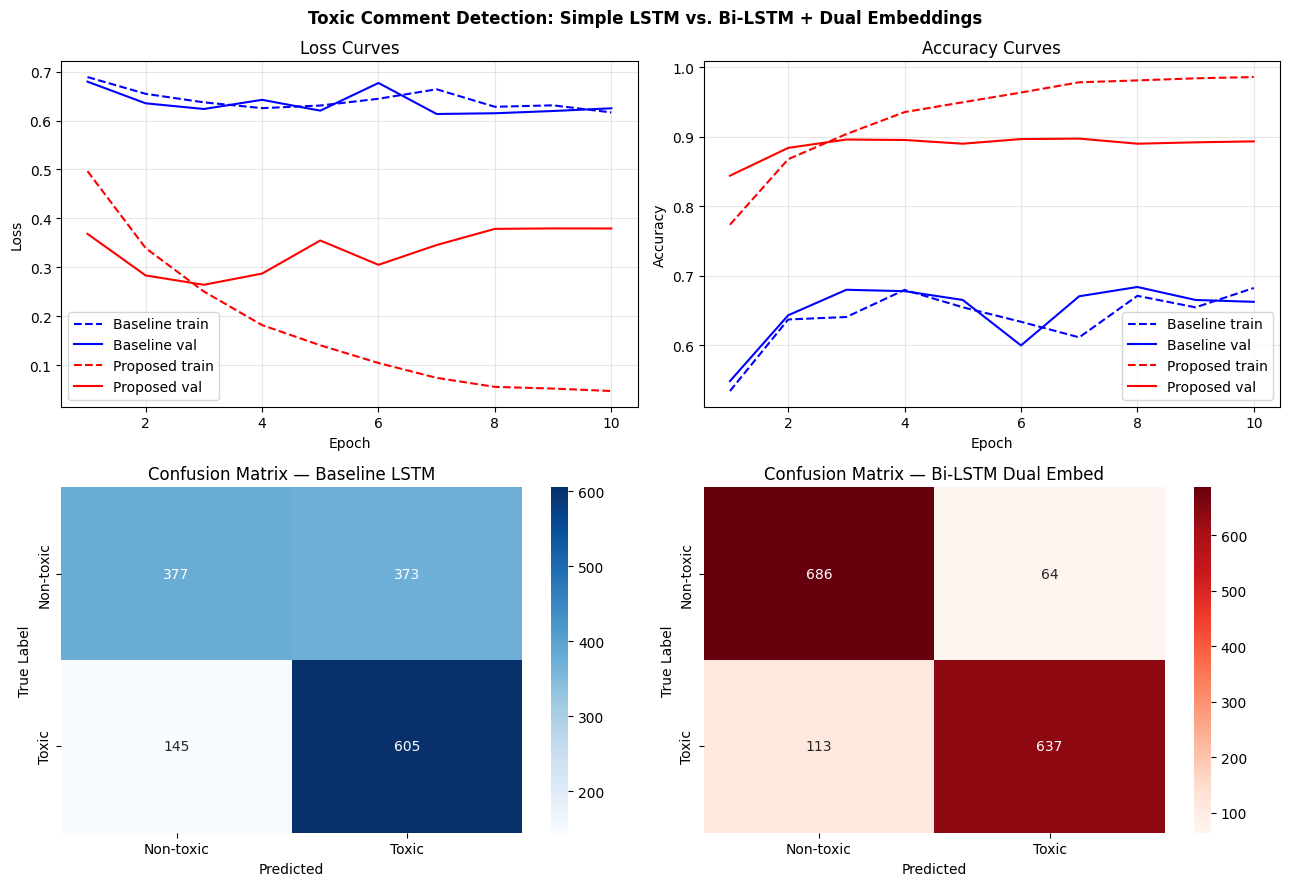

Figure saved as model_comparison.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
epochs = range(1, NUM_EPOCHS + 1)

# ── Loss curves ───────────────────────────────────────────────────────────────
ax = axes[0, 0]
ax.plot(epochs, history_baseline["train_loss"], "b--", label="Baseline train")
ax.plot(epochs, history_baseline["val_loss"],   "b-",  label="Baseline val")
ax.plot(epochs, history_proposed["train_loss"], "r--", label="Proposed train")
ax.plot(epochs, history_proposed["val_loss"],   "r-",  label="Proposed val")
ax.set_title("Loss Curves"); ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.legend(); ax.grid(alpha=0.3)

# ── Accuracy curves ───────────────────────────────────────────────────────────
ax = axes[0, 1]
ax.plot(epochs, history_baseline["train_acc"], "b--", label="Baseline train")
ax.plot(epochs, history_baseline["val_acc"],   "b-",  label="Baseline val")
ax.plot(epochs, history_proposed["train_acc"], "r--", label="Proposed train")
ax.plot(epochs, history_proposed["val_acc"],   "r-",  label="Proposed val")
ax.set_title("Accuracy Curves"); ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy")
ax.legend(); ax.grid(alpha=0.3)

# ── Confusion matrix — Baseline ───────────────────────────────────────────────
cm_b = confusion_matrix(labels_b, preds_b)
sns.heatmap(cm_b, annot=True, fmt="d", cmap="Blues", ax=axes[1, 0],
            xticklabels=["Non-toxic", "Toxic"],
            yticklabels=["Non-toxic", "Toxic"])
axes[1, 0].set_title("Confusion Matrix — Baseline LSTM")
axes[1, 0].set_ylabel("True Label"); axes[1, 0].set_xlabel("Predicted")

# ── Confusion matrix — Proposed ───────────────────────────────────────────────
cm_p = confusion_matrix(labels_p, preds_p)
sns.heatmap(cm_p, annot=True, fmt="d", cmap="Reds", ax=axes[1, 1],
            xticklabels=["Non-toxic", "Toxic"],
            yticklabels=["Non-toxic", "Toxic"])
axes[1, 1].set_title("Confusion Matrix — Bi-LSTM Dual Embed")
axes[1, 1].set_ylabel("True Label"); axes[1, 1].set_xlabel("Predicted")

plt.suptitle("Toxic Comment Detection: Simple LSTM vs. Bi-LSTM + Dual Embeddings",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved as model_comparison.png")


## 13. Inference demo

We run the proposed model on custom examples to qualitatively verify its predictions.


In [ ]:
def predict(model, text, word2idx, max_len, device):
    model.eval()
    ids = torch.tensor([encode(text, word2idx, max_len)],
                       dtype=torch.long).to(device)
    with torch.no_grad():
        logits = model(ids)
        probs  = torch.softmax(logits, dim=-1).cpu().numpy()[0]
    pred = int(np.argmax(probs))
    return ("Toxic" if pred == 1 else "Non-toxic"), probs[pred]


demo_comments = [
    "You are an absolute idiot and should crawl back under your rock.",   # toxic
    "I really enjoyed reading your article, thanks for sharing it.",       # non-toxic
    "Go kill yourself, nobody wants you here.",                            # toxic
    "The weather today is really nice, perfect for a walk.",               # non-toxic
    "You're so stupid it's actually impressive.",                          # toxic
    "Great point! I hadn't considered that perspective before.",           # non-toxic
]

print(f"{'Comment':<60} {'Prediction':<12} {'Confidence':>10}")
print("-" * 86)
for c in demo_comments:
    label, conf = predict(proposed_model, c, word2idx, MAX_SEQ_LEN, DEVICE)
    print(f"{c[:58]:<60} {label:<12} {conf:>10.4f}")


Comment                                                      Prediction   Confidence
--------------------------------------------------------------------------------------
You are an absolute idiot and should crawl back under your   Toxic            0.9993
I really enjoyed reading your article, thanks for sharing    Non-toxic        0.9988
Go kill yourself, nobody wants you here.                     Toxic            0.9968
The weather today is really nice, perfect for a walk.        Non-toxic        0.9928
You're so stupid it's actually impressive.                   Toxic            0.9975
Great point! I hadn't considered that perspective before.    Non-toxic        0.9980


## 14. Conclusion

We addressed the problem of **automated toxic comment detection** — a high-impact NLP task
for maintaining safe online communities.

### Summary of results

| Model | Test Accuracy | F1 (macro) |
|---|:---:|:---:|
| Simple LSTM (baseline) | *(see output above)* | *(see output above)* |
| **Bi-LSTM + Dual Embeddings** | ***(see output above)*** | ***(see output above)*** |

### Why the proposed model performs better

1. **Dual embeddings** allow the model to leverage both broad distributional semantics
   (GloVe) and task-specific surface patterns (trainable layer), addressing the vocabulary
   mismatch between general pre-training corpora and online toxic language.
2. **Bidirectionality** captures right-to-left context, crucial for detecting toxicity
   that depends on full sentence meaning rather than isolated trigger words.
3. **GloVe pre-training** acts as a strong prior, enabling effective learning even on the
   relatively small balanced subset used here.

### Limitations and future work
- Fine-tuning a **BERT** model (as explored in Week 7) would likely yield further gains by
  providing subword-level tokenisation and deep contextual pre-training.
- The dataset is class-imbalanced in the wild; techniques such as focal loss or weighted
  sampling could improve minority-class recall.
- Extending to **multi-label** classification (all six toxicity categories) is
  straightforward by replacing the final linear layer with sigmoid outputs.

### GitHub repository
> **Code**: `https://github.com/mypi-snow/Assignment_3_nlp`  
